In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


## Imports

In [3]:
import os
import sys
import torch

from torchvision import datasets
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

PROJECT_ROOT = "/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.imputation import create_center_mask, impute_image_ou
from src.diffusion_utilities import plot_image_grid

## Device

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


## Cargar imagen

In [5]:
transform = Compose([
    Resize((32, 32)),
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

desired_digit = 4

indices = torch.where(data.targets == desired_digit)[0]
idx = indices[0]  # puedes cambiar esto por otro

image, label = data[idx]
image = image.unsqueeze(0).to(device)

print("Digit:", label)

Digit: 4


## Crear imagen tapada

In [6]:
mask = create_center_mask(
    image_shape=image.shape,
    box_size=12,
    device=device,
)

masked_image = image * mask

## Imputar

In [7]:
checkpoint_path = "./checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch500.pth"

imputed_image = impute_image_ou(
    image=image,
    mask=mask,
    checkpoint_path=checkpoint_path,
    n_steps=2000,
    n_corrector_steps=3,
    snr=0.10,
    device=device,
)

## Mostrar resultado

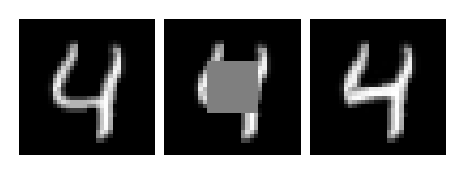

In [8]:
_ = plot_image_grid(
    images=torch.cat([image, masked_image, imputed_image], dim=0),
    figsize=(6, 2),
    n_rows=1,
    n_cols=3,
)